# Preparing training data for an AI model

Authors:

## Learning goals
- Prepare training data
- Use napari to check and improve annotations
- Use public imaging data to train an AI model
# some of the code is based on https://github.com/IDR/idr-notebooks/

Public repositories like IDR (https://idr.openmicroscopy.org/) and BIA (https://www.ebi.ac.uk/bioimage-archive/) contain a lot of public data that can be used to train AI models.

IDR data that can be explored via a public OMERO instance. It is also possible to access the raw data in Python and use it for analysis or training of AI models.

In this tutorial we will use some images part of a large Cell Paining screen.
The images consists of several markers. 

The goal of this tutorial train an AI model to detect nuclei from the actin (phalloidin) channel. This would allow API channel to segment the nuclei. 
This would allow in a new study to use the DAPI channel for another marker.

We can use the DAPI channel available in thedata to create ground-truth segmentations.

Explore the data here in your browser: https://idr.openmicroscopy.org/webclient/?show=screen-1952

The paper related to the data is linked directly at the IDR, but you can also check it out here directly: https://doi.org/10.1371/journal.pone.0080999  

## Setup

While the IDR is based on OMERO, it is not anymore possible to access the data through the OMERO API (Application Programming Interface). Instead the data can be explored programaticaly via a web API. Then you can find the right data you like to use. The data is stored as OME-zarr files.

In [1]:
# Explore data
from IPython.display import display, HTML
import requests


In [2]:
IDR_BASE_URL = "https://idr.openmicroscopy.org"
MAP_URL = "{base}/webclient/api/annotations/?type=map&{type}={screen_id}"
PLATES_URL = "{base}/webclient/api/plates/?id={screen_id}"

# Here we need to set the screen ID for the dataset we want to explore. 
# The screen ID is a unique identifier for a specific dataset in the IDR (Image Data Resource). 
# You can find the screen ID in the URL of the dataset page on the IDR website. 
# For example, if the URL is "https://idr.openmicroscopy.org/webclient/?show=screen-1952", then the screen ID is 1952.
SCREEN_ID = 1952

We need to create a "http" session which we can use to extract metadata from the IDR

In [3]:
INDEX_PAGE = f"{IDR_BASE_URL}/webclient/?experimenter=-1"
# create http session
with requests.Session() as session:
    request = requests.Request('GET', INDEX_PAGE)
    prepped = session.prepare_request(request)
    response = session.send(prepped)
    if response.status_code != 200:
        response.raise_for_status()
print(f"Connected to IDR at {IDR_BASE_URL} with status code {response.status_code}")

Connected to IDR at https://idr.openmicroscopy.org with status code 200


Now we can print some information of the study (That information is also available on the website)

In [4]:
# Now we can print the metadata available on this screen
qs = {'base': IDR_BASE_URL, 'type': 'screen', 'screen_id': SCREEN_ID}
url = MAP_URL.format(**qs)
for a in session.get(url).json()['annotations']:
    namespace = a['ns']
    for v in a['values']:
        key = v[0]
        value = v[1]
        print(key, value)


Sample Type cell
Organism Homo sapiens
Study Title Human U2OS cells - compound-profiling Cell Painting experiment
Study Type high content screen
Screen Type primary screen
Screen Technology Type compound screen
Imaging Method fluorescence microscopy
Publication Title Multiplex cytological profiling assay to measure diverse cellular states.
Publication Authors Gustafsdottir SM, Ljosa V, Sokolnicki KL, Anthony Wilson J, Walpita D, Kemp MM, Petri Seiler K, Carrel HA, Golub TR, Schreiber SL, Clemons PA, Carpenter AE, Shamji AF
PubMed ID 24312513 https://www.ncbi.nlm.nih.gov/pubmed/24312513
PMC ID PMC3847047 https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3847047
Publication DOI 10.1371/journal.pone.0080999 https://doi.org/10.1371/journal.pone.0080999
Release Date 2017-09-22
License CC0 1.0 https://creativecommons.org/publicdomain/zero/1.0/
Copyright Waived by Anne Carpenter
External URL https://www.broadinstitute.org/bbbc/BBBC022/
External URL http://www.cellimagelibrary.org/pages/project_202

We can for example also ask which plates are 

In [5]:
qs = {'base': IDR_BASE_URL, 'screen_id': SCREEN_ID}
url = PLATES_URL.format(**qs)

for p in session.get(url).json()['plates']:
    plate_id = p['id']
    print("Plate ID: {id}, Name: {name}".format(**p))
    # create a dictionary with plated id and name


Plate ID: 4403, Name: 20585
Plate ID: 5352, Name: 20586
Plate ID: 4705, Name: 20589
Plate ID: 4881, Name: 20590
Plate ID: 4883, Name: 20591
Plate ID: 4884, Name: 20592
Plate ID: 4886, Name: 20593
Plate ID: 4887, Name: 20594
Plate ID: 4889, Name: 20595
Plate ID: 4890, Name: 20596
Plate ID: 4892, Name: 20607
Plate ID: 4893, Name: 20608
Plate ID: 4895, Name: 20625
Plate ID: 4896, Name: 20626
Plate ID: 4898, Name: 20630
Plate ID: 4899, Name: 20633
Plate ID: 4900, Name: 20639
Plate ID: 4902, Name: 20640
Plate ID: 4903, Name: 20641
Plate ID: 4905, Name: 20646


In [6]:
WELLS_IMAGES_URL = "{base}/webgateway/plate/{plate_id}/{field}/"
plate_id = 4403

qs = {'base': IDR_BASE_URL, 'plate_id': plate_id, 'field': 0}
url = WELLS_IMAGES_URL.format(**qs)
grid = session.get(url).json()
rowlabels = grid['rowlabels']
collabels = grid['collabels']
for r, row in enumerate(grid['grid']):
    for c, cell in enumerate(row):
        if cell is not None:
            well_name = f"{rowlabels[r]}{collabels[c]}"
            print(f"Well: {well_name}, Image: {cell['id']}")

Well: A1, Image: 1895787
Well: A2, Image: 1896562
Well: A3, Image: 1898848
Well: A4, Image: 1895977
Well: A5, Image: 1897192
Well: A6, Image: 1898047
Well: A7, Image: 1896535
Well: A8, Image: 1896580
Well: A9, Image: 1896049
Well: A10, Image: 1896589
Well: A11, Image: 1897282
Well: A12, Image: 1897273
Well: A13, Image: 1898533
Well: A14, Image: 1896193
Well: A15, Image: 1898479
Well: A16, Image: 1897930
Well: A17, Image: 1897615
Well: A18, Image: 1897921
Well: A19, Image: 1895986
Well: A20, Image: 1896670
Well: A21, Image: 1898650
Well: A22, Image: 1896310
Well: A23, Image: 1896895
Well: A24, Image: 1896850
Well: B1, Image: 1897093
Well: B2, Image: 1898182
Well: B3, Image: 1896796
Well: B4, Image: 1896814
Well: B5, Image: 1898929
Well: B6, Image: 1896031
Well: B7, Image: 1896859
Well: B8, Image: 1895851
Well: B9, Image: 1898308
Well: B10, Image: 1896922
Well: B11, Image: 1898056
Well: B12, Image: 1897201
Well: B13, Image: 1897723
Well: B14, Image: 1897453
Well: B15, Image: 1896157
Well

Pick one image on check the metadata

In [7]:
# Now we can print the metadata available on a particular image
IMAGE_ID = 1898190
qs = {'base': IDR_BASE_URL, 'type': 'image', 'screen_id': IMAGE_ID}
url = MAP_URL.format(**qs)
for a in session.get(url).json()['annotations']:
    namespace = a['ns']
    for v in a['values']:
        key = v[0]
        value = v[1]
        print(key, value)

Cell Line U2OS
Compound Name ML9
Compound Name URL https://www.ncbi.nlm.nih.gov/pccompound?term=ML9
Compound Broad Identifier BRD-K68402494-001-04-7
Compound Broad Identifier URL https://pubchem.ncbi.nlm.nih.gov/compound/BRD-K68402494-001-04-7
Compound Broad Identifier Short BRD-K68402494
Compound Source Biomol International Inc.
Compound SMILES Clc1cccc2c(cccc12)S(=O)(=O)N3CCCNCC3
PubChem InChIKey OZSMSRIUUDGTEP-UHFFFAOYSA-N
Dose 7.70 micromolar
Organism Homo sapiens
Channels Hoechst 33342:nucleus;concanavalin A (con A) AlexaFluor488 conjugate:endoplasmic reticulumn;SYTO 14 green fluorescent nucleic acid stain:nucleoli;wheat germ agglutinin (WGA) AlexaFluor594 conjugate:Golgi apparatus and plasma membrane;phalloidin AlexaFluor594 conjugate:F-actin;MitoTracker Deep Red: mitochondria
In Annotated Set yes
GO Annotation GO:0004697 (inhibits protein kinase C activity)


Check which markers are in the image

In [8]:
annotations = session.get(url).json()['annotations']

meta = {k: v for a in annotations for k, v in a["values"]}

channels = [c.split(":", 1) for c in meta["Channels"].split(";")]
channels = {i: (dye.strip(), target.strip()) for i, (dye, target) in enumerate(channels)}

for i, (dye, target) in channels.items():
    print(i, dye, "->", target)


0 Hoechst 33342 -> nucleus
1 concanavalin A (con A) AlexaFluor488 conjugate -> endoplasmic reticulumn
2 SYTO 14 green fluorescent nucleic acid stain -> nucleoli
3 wheat germ agglutinin (WGA) AlexaFluor594 conjugate -> Golgi apparatus and plasma membrane
4 phalloidin AlexaFluor594 conjugate -> F-actin
5 MitoTracker Deep Red -> mitochondria


Get the URL/location of the data for the image we are interested in. 

In [9]:
# Pick one image

IMAGE_DETAILS_URL = "{base}/api/v0/m/images/{image_id}/"
IMAGE_ID = 1898190

qs = {'base': IDR_BASE_URL, 'image_id': IMAGE_ID}
url = IMAGE_DETAILS_URL.format(**qs)

r = session.get(url).json()

# Images backed by OME-Zarr will link to the zarr data via the image externalInfo
image_details = r["data"]["omero:details"]
is_zarr = "externalInfo" in image_details and image_details["externalInfo"]["EntityType"] == "com.glencoesoftware.ngff:multiscales"

print("Is Zarr?", is_zarr)
zarr_url = None
if (is_zarr):
    externalInfo_lsid = image_details["externalInfo"]["Lsid"]
    print(externalInfo_lsid)
    zarr_url = externalInfo_lsid.replace("s3:", "https:").replace("?anonymous=true", "")
    zarr_url = zarr_url.rstrip("/")
    display(HTML(f"Open <a href='https://ome.github.io/ome-ngff-validator/?source={zarr_url}'>image in NGFF-validator</a>"))



Is Zarr? True
s3://livingobjects.ebi.ac.uk/bioimaging-integrator-data/S-BIAD855/781ac3d7-673f-47be-a4d2-3fdf3f477047/781ac3d7-673f-47be-a4d2-3fdf3f477047.zarr/B/2/8?anonymous=true


In [10]:
data = None
if zarr_url:
    import zarr
    import dask.array as da
    img_group = zarr.open(zarr_url)
    attrs = img_group.attrs.asdict()
    ds_paths = [ds["path"] for ds in attrs["multiscales"][0]["datasets"]]
    print("dataset paths", ds_paths)

    # Load dask array for smallest (last) dataset resolution
    data = da.from_zarr(f"{zarr_url}/{ds_paths[-3]}")
    # T, C, Z, Y, X
    print("array shape", data.shape)

dataset paths ['0', '1', '2', '3']
array shape (5, 260, 348)


### Display one of the channels
You can change the channel parameter

extra_dims [2]
(260, 348)


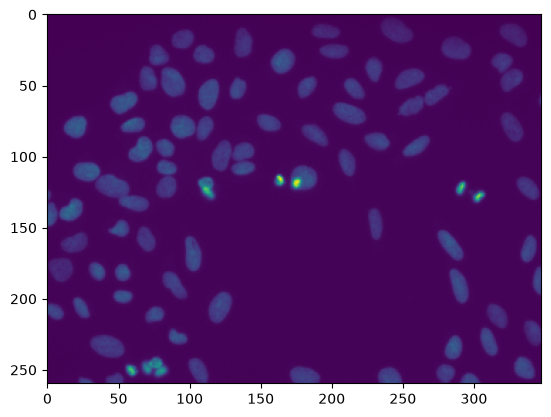

In [11]:
from matplotlib.pyplot import imshow
%matplotlib inline

channel = 2

if data is not None:
    # load the first plane (z, c, t = 0)
    extra_dims = [channel] * (data.ndim - 2)
    print("extra_dims", extra_dims)
    # we slice away any Z/C/T dims, leaving Y and X
    to_slice = (*extra_dims, slice(None), slice(None))
    plane = data[to_slice]
    print(plane.shape)
    # plane is a 2D numpy array
    imshow(plane)



In [12]:
#Get the plane and save as a numpy array
import numpy as np
import matplotlib.pyplot as plt

# data is T, C, Z, Y, X -> pick one channel, first timepoint and z-slice
channel = 2
img = np.asarray(plane)
print("plane shape", img.shape)


plane shape (260, 348)


## Making the labels with StarDist

To train a network we need a *label image*: every nucleus a different number.

We could threshold the DAPI channel and split touching nuclei with a watershed, but
that needs tuning for every image, and touching nuclei are exactly where it goes
wrong. On day 2 we saw that a pretrained StarDist model does this job directly, so we
use that instead.

Note what we are doing here: the DAPI channel is only used to *make* the labels. The
network we train later never sees it — its input is the phalloidin channel. That is
the whole point: afterwards we can find nuclei without spending a channel on DAPI.

In [18]:
from stardist.models import StarDist2D
from csbdeep.utils import normalize

# Pretrained model for fluorescent nuclei, downloaded the first time it is used
model_nuclei = StarDist2D.from_pretrained('2D_versatile_fluo')

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


### Prediction on one image

As on day 2, the image is normalized before prediction, and the object size has to
match what the model was trained on. These images come from a low resolution level of
the pyramid, so the nuclei are small and we may have to *enlarge* them with `scale`
rather than shrink them.

In [19]:
# scale > 1 enlarges the image before prediction, scale < 1 shrinks it
SCALE = 1.0

img_norm = normalize(img, 1, 99.8)
labels, _ = model_nuclei.predict_instances(img_norm, scale=SCALE)

print(f'found {labels.max()} nuclei')

found 89 nuclei


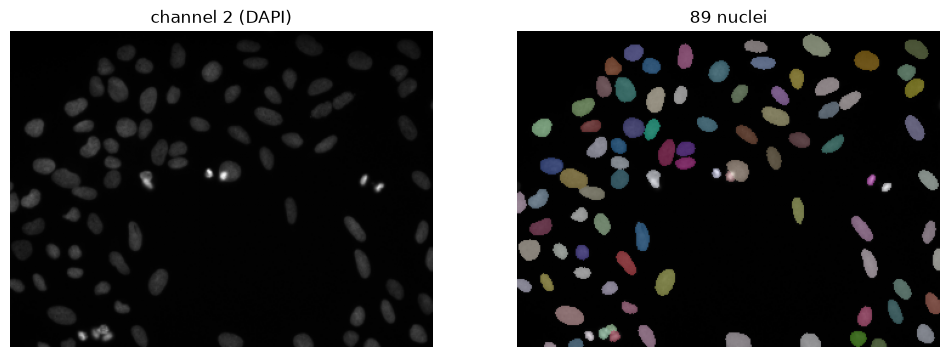

In [20]:
from stardist import random_label_cmap

lbl_cmap = random_label_cmap()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'channel {channel} (DAPI)')
axes[1].imshow(img, cmap='gray')
axes[1].imshow(labels, cmap=lbl_cmap, alpha=0.5)
axes[1].set_title(f'{labels.max()} nuclei')
for ax in axes:
    ax.axis('off')

### Check the size of the objects

Rather than guessing whether the scale was right, we measure the nuclei that were
found. If they are only a few pixels across, the model is working far below the size
it was trained on and `SCALE` should go up.

In [21]:
from skimage.measure import regionprops

diameters = [p.equivalent_diameter_area for p in regionprops(labels)]
print(f'median nucleus diameter: {np.median(diameters):.1f} pixels')

median nucleus diameter: 14.8 pixels


### Remove small objects

StarDist sometimes detect tiny objects: debris, bright spots or fragments of a nucleus.
We do not want the network to learn these, so we remove objects that is much
smaller than a typical nucleus. The minimum size is a fraction of the median area, so
it follows the resolution of the image.

In [26]:
from skimage.morphology import remove_small_objects
from skimage.segmentation import relabel_sequential

# Objects smaller than a quarter of the median nucleus area count as debris
min_area = 0.5 * np.median([p.area for p in regionprops(labels)])


def filter_small_objects(labels, min_area=min_area):
    """Remove objects of min_area pixels or smaller and renumber the labels 1..N."""
    filtered = remove_small_objects(labels, max_size=min_area)
    return relabel_sequential(filtered)[0]


labels_filtered = filter_small_objects(labels)
print(f'minimum area: {min_area:.0f} pixels')
print(f'{labels.max()} objects before, {labels_filtered.max()} after filtering')

minimum area: 86 pixels
89 objects before, 78 after filtering


saved labels_1898190.npy


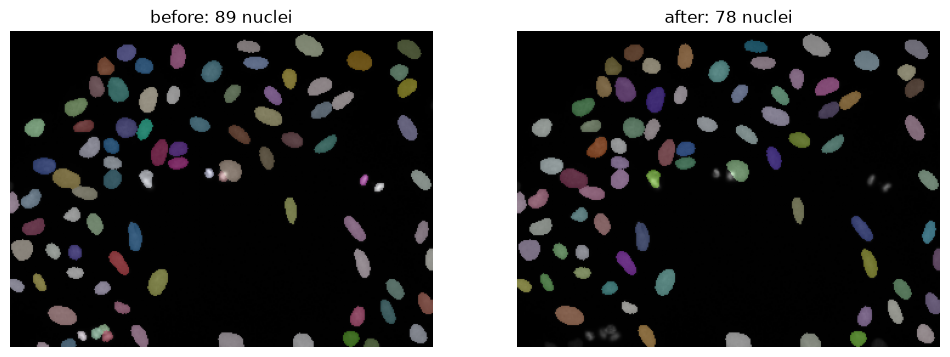

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, lbl, title in zip(axes, [labels, labels_filtered], ['before', 'after']):
    ax.imshow(img, cmap='gray')
    ax.imshow(lbl, cmap=lbl_cmap, alpha=0.5)
    ax.set_title(f'{title}: {lbl.max()} nuclei')
    ax.axis('off')

# Save the filtered labels for further analysis
np.save(f'labels_{IMAGE_ID}.npy', labels_filtered)
print('saved', f'labels_{IMAGE_ID}.npy')

## Building the dataset

We now repeat this for a set of images and write two folders:

- `training_data/images/` — the phalloidin channel, the input for the network
- `training_data/labels/` — the StarDist nuclei, the target

The two folders use the same file names, so an image and its labels always belong
together. Splitting this into training, validation and test sets happens in the next
notebook, so that the split is a deliberate choice rather than a side effect of how
the data was downloaded.

In [28]:
import random

TRAIN_CHANNEL = 4    # phalloidin, the input for the network
NUCLEI_CHANNEL = 2   # DAPI, used only to make the labels
N_IMAGES = 30        # more images is better, but each one has to be downloaded

image_ids = [c['id'] for row in grid['grid'] for c in row if c is not None]
print('images in plate:', len(image_ids))

random.seed(0)  # same subset every run
subset = random.sample(image_ids, N_IMAGES)

images in plate: 384


In [29]:
def load_image(image_id, resolution=-3):
    """Load an IDR image as a dask array (lowest resolution by default)."""
    url = IMAGE_DETAILS_URL.format(base=IDR_BASE_URL, image_id=image_id)
    lsid = session.get(url).json()['data']['omero:details']['externalInfo']['Lsid']
    zarr_url = lsid.replace('s3:', 'https:').replace('?anonymous=true', '').rstrip('/')
    paths = [ds['path'] for ds in zarr.open(zarr_url).attrs.asdict()['multiscales'][0]['datasets']]
    return da.from_zarr(f'{zarr_url}/{paths[resolution]}')

one image shape (C, Y, X): (5, 260, 348)


Text(0.5, 0.98, 'training input: channel 4 (phalloidin)')

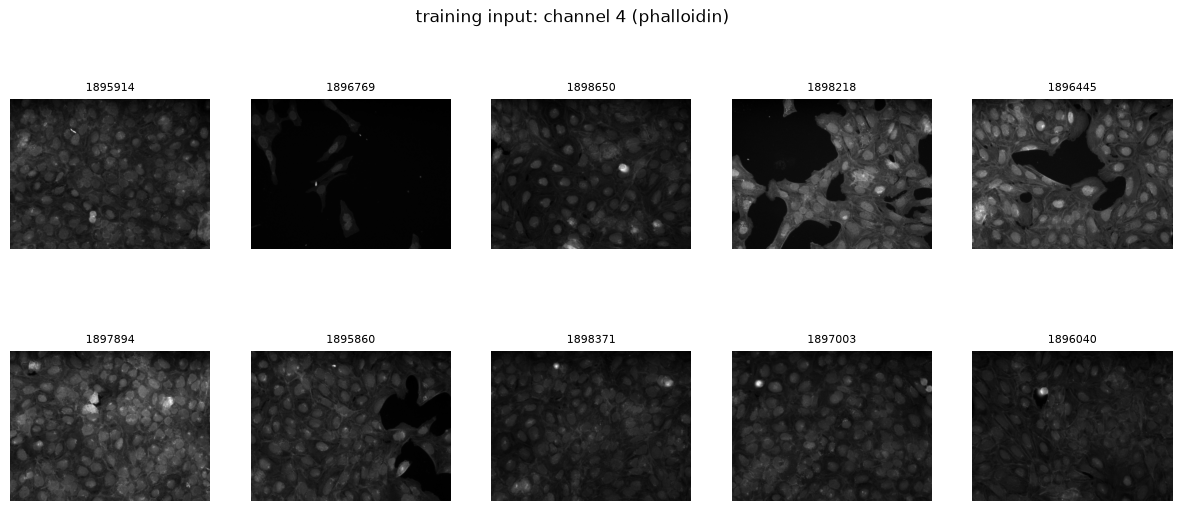

In [30]:
import zarr
import dask.array as da

# Download the subset once and keep it in memory (C, Y, X per image)
raw = [np.asarray(load_image(i)) for i in subset]
print('one image shape (C, Y, X):', raw[0].shape)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, im, image_id in zip(axes.ravel(), raw, subset):
    ax.imshow(im[TRAIN_CHANNEL], cmap='gray')
    ax.set_title(image_id, fontsize=8)
    ax.axis('off')
fig.suptitle(f'training input: channel {TRAIN_CHANNEL} (phalloidin)')

In [31]:
from pathlib import Path
import tifffile

OUT = Path('training_data')
(OUT / 'images').mkdir(parents=True, exist_ok=True)
(OUT / 'labels').mkdir(parents=True, exist_ok=True)


def segment_nuclei(plane, scale=SCALE):
    """Normalize the DAPI plane and return the filtered StarDist nuclei as a label image."""
    labels, _ = model_nuclei.predict_instances(normalize(plane, 1, 99.8), scale=scale)
    labels = filter_small_objects(labels)
    return labels


for image_id, im in zip(subset, raw):
    tifffile.imwrite(OUT / 'images' / f'{image_id}.tif', im[TRAIN_CHANNEL].astype('uint16'))
    tifffile.imwrite(OUT / 'labels' / f'{image_id}.tif', segment_nuclei(im[NUCLEI_CHANNEL]).astype('uint16'))

print(f'wrote {len(subset)} image/label pairs to {OUT.resolve()}')

wrote 30 image/label pairs to /var/home/maartenpaul/Documents/GitHub/NL-BioImageAnalysis-course2026/day_3/AI_training/training_data


## Checking and correcting the labels in napari

The labels were made by a model, not by a person, so some of them might not be exactly how we want it. 
Whatever is annotated hiere will be learned by the network we train next: **a model cannot be better
than its labels.** So before training we look at them and make revisions.

Step through the images with the slider and compare the labels against the DAPI
channel.

In [ ]:
import napari

nuclei = np.stack([im[NUCLEI_CHANNEL] for im in raw])
inputs = np.stack([im[TRAIN_CHANNEL] for im in raw])
# Read the labels back from disk, so we check what was actually saved
label_stack = np.stack([tifffile.imread(OUT / 'labels' / f'{i}.tif') for i in subset])

viewer = napari.Viewer()
viewer.add_image(nuclei, name=f'channel {NUCLEI_CHANNEL} (DAPI)', colormap='gray')
viewer.add_image(inputs, name=f'channel {TRAIN_CHANNEL} (input)', colormap='green',
                 blending='additive', visible=False)
viewer.add_labels(label_stack, name='labels', opacity=0.4)
viewer.dims.axis_labels = ('image', 'y', 'x')

Annotation tips

One nucleus split into two labels
- Pick the colour picker (5), click the colour you want to keep, then the fill bucket
  (4) and click the other piece.

Two nuclei sharing one label
- Press *new* next to the label, take the brush with size 1 and draw the line between
  the two nuclei, then fill one of them with a new label.

In [ ]:
# Write the corrected labels back to disk.
# napari edits label_stack in place, so this works whether the viewer is open or closed.
for image_id, corrected in zip(subset, label_stack):
    tifffile.imwrite(OUT / 'labels' / f'{image_id}.tif', corrected.astype('uint16'))
    print(image_id, '->', np.unique(corrected).size - 1, 'nuclei')

print('labels updated in', (OUT / 'labels').resolve())

## Next

`training_data/` now holds the input images and their labels. In `training.ipynb` we
split them into training, validation and test sets and train a model with BiaPy.